In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp

In [2]:
from functions import fit, conversion  # double check with originals from other m5 notebook

In [3]:
# input data: virtual meters for h and v
# h
# NEW FOR EACH RUN:
h1 = unp.uarray([-133,-56.10], [5,5]) # coordinates in virt m 
h2 = unp.uarray([88.64,-58.76], [5,5]) # virt m
# v 
#v1 = unp.uarray([22.02,-794.6], [10,10]) # virt m
#v2 = unp.uarray([-16.84,-126.1], [10,10]) # virt m

print(conversion(h1,h2))

0.208+/-0.007


In [4]:
# calculate G , incl uncertainties
def G_12(theta1, theta2, T, conversion_factor):
    #technical drawing
    m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

    #I = m*l**2/2 #kg m^2, using MIT estimated formula
    l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
    #l=unp.uarray(0.12, 0.001)
    rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
    #I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
    I = m*l**2/2 #kg m^2, using MIT estimated formula
    
    # laser meas
    L =  unp.uarray(4.321, 0.001) #m
        
    #measured:
    M = unp.uarray(1.5,0.01)  #kg +/-10g
    
    #delta_r = 0.003 #possible systematic on r
    delta_r = 0.0
    r = unp.uarray(0.061  + delta_r, 0.005) #m  51.722+/-0.011 #meas with messschieber in the air, could be improved

        
    #fit: T0, dtheta1, dtheta2
    h1=theta1*conversion_factor #conversion factor for vid setup 1 in cm/'m'. used squared addition here
    h2=theta2*conversion_factor
    
    #dtheta= unp.arctan( (theta2 - theta1)*0.01 / 4.321) #0.01 go from cm to m
    dtheta= unp.arctan( ((h2 - h1)*0.5)*0.01 / 4.321) #0.01 go from cm to m
        
    #units kg m^2 /s^2  * m^2/kg^2/m
    G = (r)**2 * (l)/(8*M) * (2*np.pi/T)**2 * dtheta  #using MIT I that cancels, we could get a correction here

    print('eq1:',h1,'eq2:',h2, 'in cm')
    
    return G

In [5]:
#get period T0
T =  2*np.pi/fit(*np.loadtxt('m5/m5v_p0.txt', skiprows=2, unpack=True), cutoff=500)[2]
print('period from zero measurement = ', T)

period from zero measurement =  307.4+/-0.4


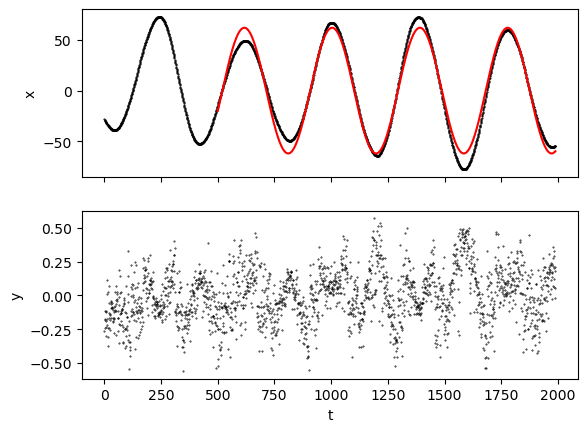

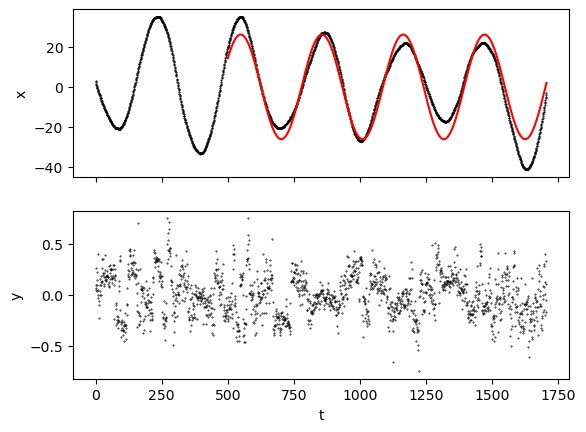

eq1: 31.2+/-1.0 eq2: 34.4+/-1.1 in cm
(9.8+/-1.6)e-11


In [6]:
#T = ufloat(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
#fit: T0, dtheta1, dtheta2
#theta1=unp.uarray(1042.074833852749, 0 ) #conversion factor for vid setup 1 in cm/'m'. used squared addition here
#theta2=unp.uarray(1249.6597283089984, 0)
theta1 = fit(*np.loadtxt('m5/m5v_p1.txt', skiprows=2, unpack=True), cutoff=500, plot=True)[4]
theta2 = fit(*np.loadtxt('m5/m5v_p0.txt', skiprows=2, unpack=True), cutoff=500, plot=True)[4]
conversion_factor =conversion(h1,h2)
print(G_12(theta1, theta2, T, conversion_factor)*2) # *2 for G01,2 